In [27]:
# MPI

import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)


print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "test_field_analysis"


## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TXY")
lattice_slab = Lattice(type="TXY", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()



bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": InP})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": air})
hole2_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": height_slab, "material": air})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D, hole2_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab, hole2_slab])

## Define the simulation

configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=20, 
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield output-hfield)",
)



mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)

from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer

# Create your Simulation instance.
simulation_2D = Simulation(simulation_name=name+"_2D",
                 script=script_2D,
                 log_level = Simulation.WARNING)

simulation_slab = Simulation(simulation_name=name+"_slab",
                    script=script_slab,
                    log_level = Simulation.WARNING)
simulation_2D.run_hpc(mpb_command_line_params={"r1":0.10, "r2":0.339})


Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
Found script param: size with value: (vector3 1e+20 1e+20 h)
Found script param: radius with value: r1
Found script param: radius with value: r2
Found script param: radius with value: r1
Found script param: height with value: h
Found script param: radius with value: r2
Found script param: height with value: h
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.3)', '(define-param r2 0.2)']


In [10]:
# MPI
import matplotlib.pyplot as plt
import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)


print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *



n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
mat = Material(epsilon = 20)
## Simulation Name: 
name = "prather"


## Define the geometry
radius = ScriptParam("r", 0.35)

## Define the lattice
lattice_2D = Lattice(type="TX")
print(lattice_2D._mp_lattice.basis)
k_points = lattice_2D.get_k_points_around_Gamma(-0.3)

k_points["k_points_values"] =  [mp.Vector3(0,0,0), mp.Vector3(-0.23, 0, 0)]
k_points["k_points_labels"] = ["G", "X"]
center = mp.Vector3(0,0,0)


bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": mat})
hole_2D = Geometry(geom_type=mp.Cylinder, params={"center": center, "radius": radius, "height": 1e20, "material": air})


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole_2D])


## Define the simulation

configuration_options = dict(
    resolution = 64, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=None,
    extra_runner_command = "(output-at-kpoint (list-ref k-points 1) fix-efield-phase output-nonbloch-efield-z output-nonbloch-hfield-y)",
)



mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)

from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer

# Create your Simulation instance.
simulation_2D = Simulation(simulation_name=name+"_2D",
                 script=script_2D,
                 log_level = Simulation.WARNING)
print(script_2D)
simulation_2D.run_hpc(mpb_command_line_params={"r":0.35})



Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
<<1.0 0.5000000000000001 0.0>
 <0.0 0.8660254037844388 0.0>
 <0.0 0.0 1.0>>
Found script param: radius with value: r
COMMANDS ['(define-param r 0.35)']
(set! num-bands 8)
(set! resolution 64)
(set! k-points (list (vector3 0.0 0.0 0.0) (vector3 -0.23 0.0 0.0)))

(define-param r 0.35)
(set! geometry-lattice (make lattice (size 1 1 no-size) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 1e+20))
  (material (make dielectric (epsilon 20))))
 (make cylinder (center (vector3 0.0 0.0 0.0))
  (radius r)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (output-field-to-file -1 (string-appen

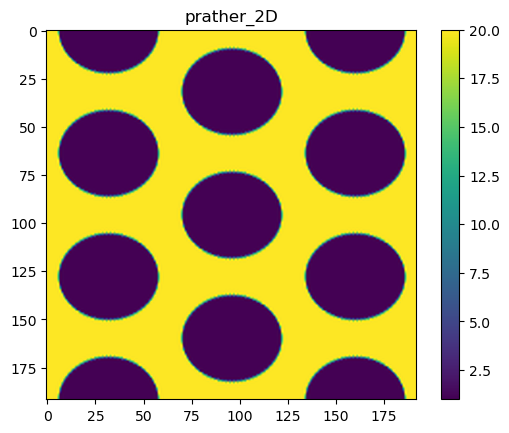

Vector3<0.23, 0.0, 0.0>
k index      1.000000
k1           0.000000
k2           0.000000
k3           0.000000
kmag/2pi     0.000000
tm band 1    0.000000
tm band 2    0.266793
tm band 3    0.286696
tm band 4    0.286717
tm band 5    0.376789
tm band 6    0.376847
tm band 7    0.468681
tm band 8    0.523005
Name: 0, dtype: float64


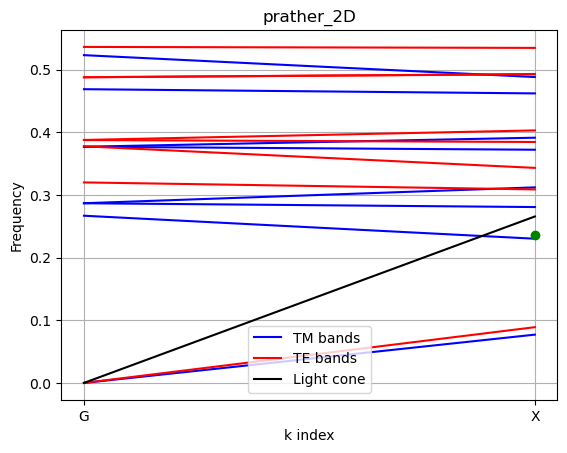

In [11]:

vwr = SimulationViewer(simulation_2D)
vwr.newfig()
vwr.plot_epsilon_2d()
vwr.show()
vwr.plot_band_diagram("tm", k_points_path=k_points, colors="blue")
vwr.plot_band_diagram("te", k_points_path=k_points, colors="red")
df = simulation_2D.load_frequency_data("tm")
target_cartesian = mp.Vector3(0.23, 0)
target_reciprocal = lattice_2D.cartesian_to_reciprocal(target_cartesian)
target_reciprocal = target_cartesian
print(target_reciprocal)
k = simulation_2D.find_closest_k_point_row(df, target_reciprocal)
print(k)

vwr.plot_light_cone(df)
plt.plot(2, 0.236, "go")
vwr.show()


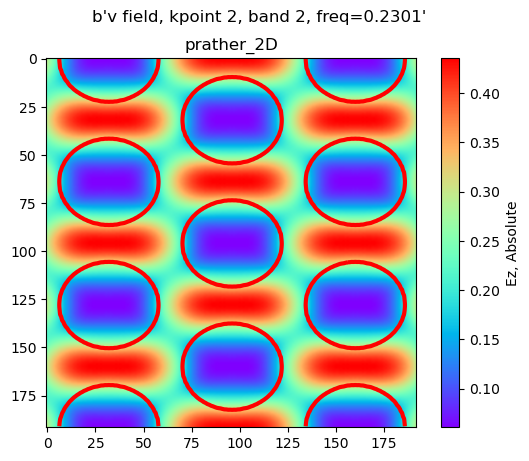

In [12]:


conversion_options = {
    "periods": 3,
    "phase": 0,
    "rectify":  True,
    
}
# vwr.newfig()
# vwr.plot_field_data(42,2,"x", "tm", "e", overlay_epsilon=True, conversion_options=conversion_options, plot_mode="real", nonbloch = True) 
# vwr.show()

# vwr.newfig()
# vwr.plot_field_data(42,2,"y", "tm", "e", overlay_epsilon=True, conversion_options=conversion_options, plot_mode="real", nonbloch = True) 
# vwr.show()

vwr.newfig()
vwr.plot_field_data(2,2,"z", "tm", "e", overlay_epsilon=True, conversion_options=conversion_options, plot_mode="abs", nonbloch = True, cmap="rainbow", file_comp = "z") 
vwr.show()

In [59]:
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer
import matplotlib.pyplot as plt



class FieldAnalyzer:
    def __init__(self,simulation: Simulation,  bands, polarization):
        self.bands = bands
        self.polarization = polarization
        self.simulation = simulation    

    def load_field_data(self, k_index, band_index, field_type, nonbloch = True, comp = "z", periods = 3):
        field =  self.simulation.load_and_convert_field_data(k_index, band_index, comp, self.polarization, field_type, 
                                                           nonbloch = nonbloch, conversion_options= {"periods": periods, "rectify":  True}, 
                                                           file_comp=comp)[0]
        
        return self.make_2D(field)
    

    
    def load_hfield_data(self, k_index, band_index, comp, periods = 3, nonbloch = True) :
        return self.load_field_data(k_index, band_index, "h", nonbloch, comp, periods)
    
    def load_efield_data(self, k_index, band_index, comp, periods = 3, nonbloch = True) :
        return self.load_field_data(k_index, band_index, "e", nonbloch, comp , periods)
    
    
    
    def make_2D(self, field_data):
        if field_data.ndim == 2:
            return field_data
        elif field_data.ndim == 3:
            return field_data[:,:,field_data.shape[2]//2]
        
    

    

    def field_less_than_zero(self, field_data):
        """Returns a boolean mask for values less than zero"""
        return field_data < 0
    
    def field_greater_than_zero(self, field_data):
        """Returns a boolean mask for values greater than zero or equal to zero"""
        return field_data >= 0
    
    
    def get_mask(self, field_data, mask_func):
        return mask_func(field_data)
    
    def mask_field_data(self, field_data, mask):
        """Mask field data by setting values where mask is False to None/np.nan
        while preserving the shape of the array"""
        masked = field_data.copy()
        masked[~mask] = 0
        return masked

    def average_2D(self, field_data):
        if field_data.ndim == 3:
            raise ValueError("Field data must be 2D")
        shape = field_data.shape
        return field_data.sum() / (shape[0] * shape[1])
    
    def average_1D(self, field_data, axis):
        if field_data.ndim == 3:
            raise ValueError("Field data must be 2D")
        if axis not in [0, 1]:
            raise ValueError("Axis must be 0 or 1")
        if axis == 0:
            return field_data[0,:].sum() / field_data.shape[1]
        elif axis == 1:
            return field_data[:,0].sum() / field_data.shape[0]
    
    
    def get_eps_mu(self, k_index, band_index, component_i, component_j, average_type = "2D", nonbloch = True, periods = 3, kmag = None, freq = None):
        e_field_i = self.load_efield_data(k_index, band_index, component_i, periods = periods, nonbloch = nonbloch)
        h_field_j = self.load_hfield_data(k_index, band_index, component_j, periods = periods, nonbloch = nonbloch)
        

        mask_I = self.get_mask(h_field_j.real, self.field_greater_than_zero)
        mask_II = self.get_mask(h_field_j.real, self.field_less_than_zero)

        # Create the masked complex fields for both regions
        e_field_i_masked_I = self.mask_field_data(e_field_i, mask_I)
        e_field_i_masked_II = self.mask_field_data(e_field_i, mask_II)
        h_field_j_masked_I = self.mask_field_data(h_field_j, mask_I)
        h_field_j_masked_II = self.mask_field_data(h_field_j, mask_II)

        
        if average_type == "2D":
            e_field_i_masked_I_avg = self.average_2D(e_field_i_masked_I)
            e_field_i_masked_II_avg = self.average_2D(e_field_i_masked_II)
            h_field_j_masked_I_avg = self.average_2D(h_field_j_masked_I)
            h_field_j_masked_II_avg = self.average_2D(h_field_j_masked_II)

        elif average_type == "1D":
            e_field_i_masked_I_avg = self.average_1D(e_field_i_masked_I, 0)
            e_field_i_masked_II_avg = self.average_1D(e_field_i_masked_II, 0)
            h_field_j_masked_I_avg = self.average_1D(h_field_j_masked_I, 0)
            h_field_j_masked_II_avg = self.average_1D(h_field_j_masked_II, 0)

            
        e_over_h_I = e_field_i_masked_I_avg.real / h_field_j_masked_I_avg.real
        e_over_h_II = e_field_i_masked_II_avg.real / h_field_j_masked_II_avg.real

        mu_I = e_over_h_I
        mu_II = e_over_h_II
        eps_I = 1/e_over_h_I
        eps_II = 1/e_over_h_II

        k_mag_over_freq = kmag/freq if kmag is not None and freq is not None else 1
        mu_I = mu_I * k_mag_over_freq
        mu= np.emath.sqrt(mu_I)*np.emath.sqrt(mu_II)
        eps = np.emath.sqrt(eps_I)*np.emath.sqrt(eps_II)

        eps = eps*k_mag_over_freq
        mu = mu*k_mag_over_freq

        return  eps, mu





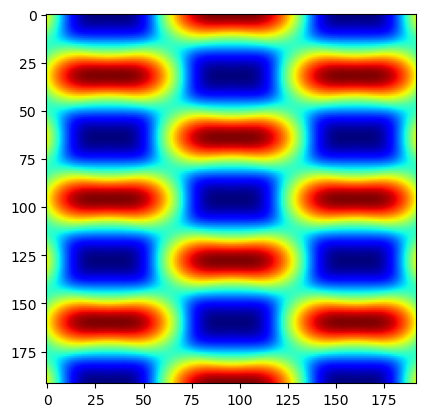

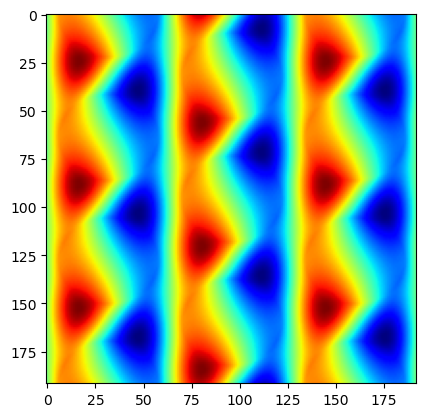

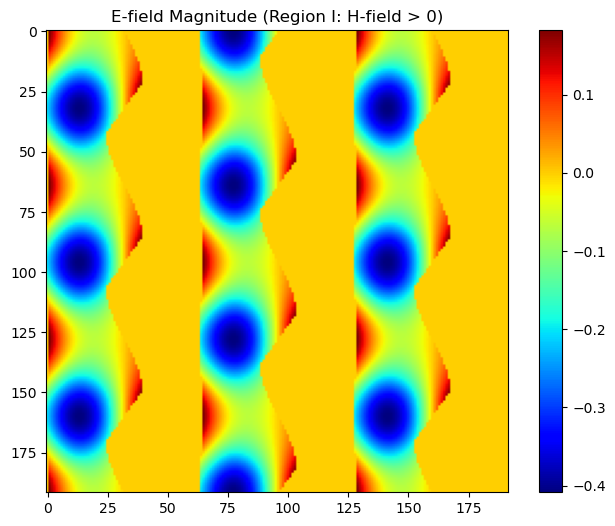

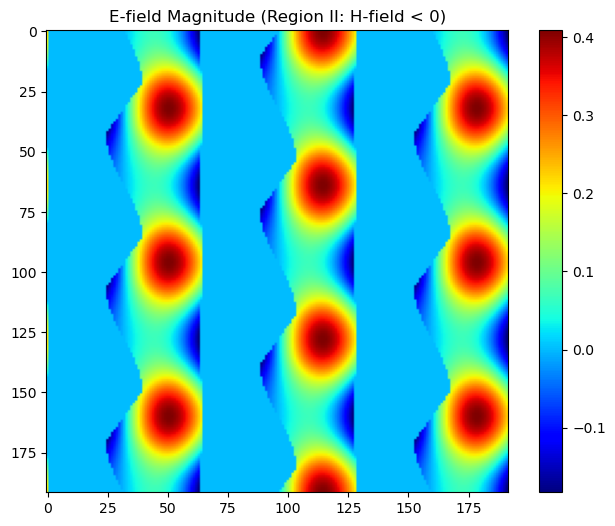

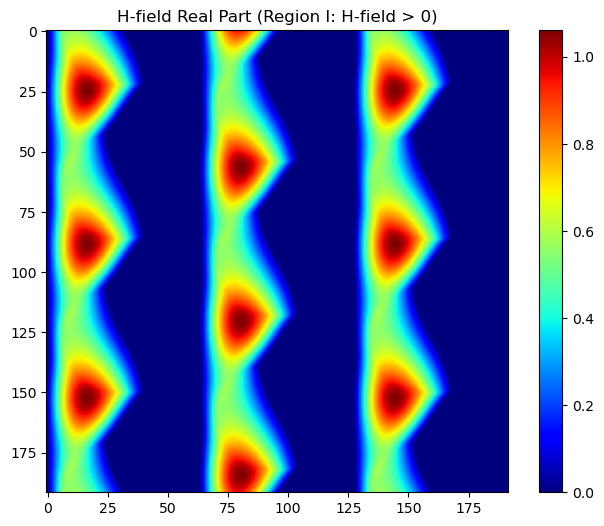

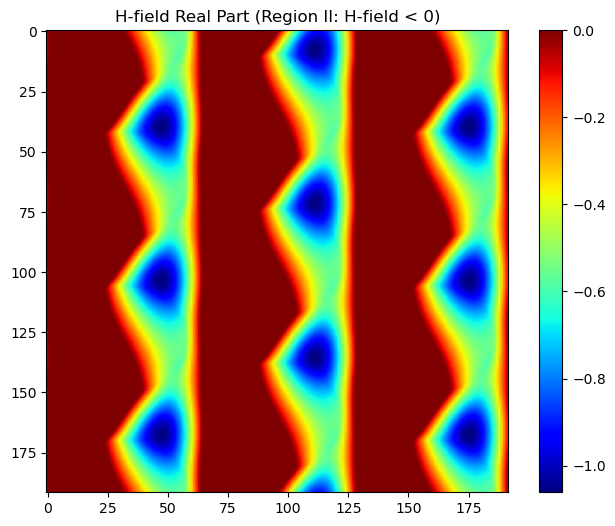

e_i_I: (-0.06676991317053987-0.008237845100117398j)
e_i_II: (0.06676991135256904-0.008146445287301114j)
h_j_I: (0.2428974775158224-0.008191369257748245j)
h_j_II: (-0.24289747613912194-0.008164146982010278j)
E/H I: -0.2748892819036808
E/H II: -0.274889275977186
Epsilon I: -3.6378282669834787
Epsilon II: -3.6378283454134945
Mu I: -0.2748892819036808
Mu II: -0.274889275977186
Epsilon: (-3.6378283061984864+0j)
Mu: (-0.2748892789404334+0j)
Epsilon: (-3.6378283061984864+0j)
Mu: (-0.2748892789404334+0j)


In [61]:
analyzer = FieldAnalyzer(simulation_2D, 1, "tm")

e_field = analyzer.load_efield_data(2, 2, "z")
h_field = analyzer.load_hfield_data(2, 2, "y")
plt.imshow(np.abs(e_field), cmap="jet")
plt.show()
plt.imshow(h_field.real, cmap="jet")
plt.show()

mask_I = analyzer.get_mask(h_field.real, analyzer.field_greater_than_zero)
mask_II = analyzer.get_mask(h_field.real, analyzer.field_less_than_zero)

e_field_masked_I = analyzer.mask_field_data(e_field, mask_I)
e_field_masked_II = analyzer.mask_field_data(e_field, mask_II)

h_field_masked_I = analyzer.mask_field_data(h_field, mask_I)
h_field_masked_II = analyzer.mask_field_data(h_field, mask_II)

plt.figure(figsize=(8, 6))
plt.imshow(e_field_masked_I.real, cmap="jet")
plt.colorbar()
plt.title("E-field Magnitude (Region I: H-field > 0)")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(e_field_masked_II.real, cmap="jet")
plt.colorbar()
plt.title("E-field Magnitude (Region II: H-field < 0)")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(h_field_masked_I.real, cmap="jet")
plt.colorbar()
plt.title("H-field Real Part (Region I: H-field > 0)")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(h_field_masked_II.real, cmap="jet")
plt.colorbar()
plt.title("H-field Real Part (Region II: H-field < 0)")
plt.show()


e_field_avg_2D_I = analyzer.average_2D(e_field_masked_I)
e_field_avg_2D_II = analyzer.average_2D(e_field_masked_II)
h_field_avg_2D_I = analyzer.average_2D(h_field_masked_I)
h_field_avg_2D_II = analyzer.average_2D(h_field_masked_II)
print("e_i_I:", e_field_avg_2D_I)
print("e_i_II:", e_field_avg_2D_II)
print("h_j_I:", h_field_avg_2D_I)
print("h_j_II:", h_field_avg_2D_II)

e_h_I = e_field_avg_2D_I.real / h_field_avg_2D_I.real
e_h_II = e_field_avg_2D_II.real / h_field_avg_2D_II.real
print("E/H I:", e_h_I)
print("E/H II:", e_h_II)
mu_I = e_h_I
mu_II = e_h_II
eps_I = 1/e_h_I
eps_II = 1/e_h_II
print("Epsilon I:", eps_I)
print("Epsilon II:", eps_II)
print("Mu I:", mu_I)
print("Mu II:", mu_II)



eps = np.emath.sqrt(eps_I)*np.emath.sqrt(eps_II)
mu = np.emath.sqrt(mu_I)*np.emath.sqrt(mu_II)
print("Epsilon:", eps)
print("Mu:", mu)


eps, mu = analyzer.get_eps_mu(2, 2, "z", "y", average_type="2D", nonbloch=True, periods=3) 
print("Epsilon:", eps)
print("Mu:", mu) 
